# **DST** para señales unidimensionales

Esta celda es para poder importar los módulos que se encuentran en la raíz del proyecto

In [1]:
import os
import sys
module_path = os.path.abspath(os.path.join('..'))
if module_path not in sys.path:
    sys.path.append(module_path)

Aquí se importan **PyWavelets**, **Matplotlib**, **Numpy** y en `dst.filters` está la implementación de que hicimos para obtener los filtros según el artículo de Guido.

In [2]:
import pywt, math
from dst.filters import get_filters
import matplotlib.pyplot as plt
import numpy as np

El patrón que se muestra a continuación es el que sale como principal ejemplo en el artículo y en nuestros experimentos

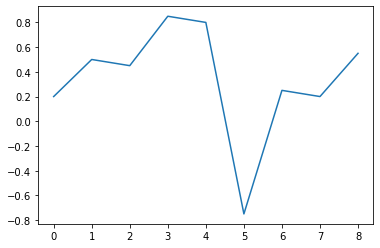

In [3]:
pattern = [0.20, 0.50, 0.45, 0.85, 0.80, -0.75, 0.25, 0.20, 0.55]
plt.plot(np.arange(0,len(pattern),1),pattern)
plt.show()

Una vez calculados los filtros, se los pasamos a `pywt.Wavelet` para crear la *wavelet* y la transformada correspondiente

In [4]:
dec_lo, dec_hi, rec_lo, rec_hi = get_filters(pattern) # get_filters return dictionaries
print(f'p: {dec_lo}\n')
print(f'q: {dec_hi}\n')
print(f'p_bar: {rec_lo}\n')
print(f'q_bar: {rec_hi}\n')

p: {p0: -0.1540042426021446, p1: 0.30351335260314144, p2: 0.33979502965492414, p3: -0.061240070093691014, p4: 0.6994123515727317, p5: 0.5001328134176583, p6: -0.14279704269840263, p7: -0.0724559569389006}

q: {q0: -0.0724559569389006, q1: 0.14279704269840263, q2: 0.5001328134176583, q3: -0.6994123515727317, q4: -0.061240070093691014, q5: -0.33979502965492414, q6: 0.30351335260314144, q7: 0.1540042426021446}

p_bar: {p_0: -0.0724559569389006, p_1: -0.14279704269840263, p_2: 0.5001328134176583, p_3: 0.6994123515727317, p_4: -0.061240070093691014, p_5: 0.33979502965492414, p_6: 0.30351335260314144, p_7: -0.1540042426021446}

q_bar: {q_0: 0.0724559569389006, q_1: 0.14279704269840263, q_2: -0.5001328134176583, q_3: -0.6994123515727317, q_4: 0.061240070093691014, q_5: -0.33979502965492414, q_6: -0.30351335260314144, q_7: 0.1540042426021446}



Estos son lo que se obtienen en el artículo

In [5]:
from scripts.values import q_values, q_bar_values, p_values, p_bar_values
print(f'p: {p_values}\n')
print(f'q: {q_values}\n')
print(f'p_bar: {p_bar_values}\n')
print(f'q_bar: {q_bar_values}\n')

p: {p0: -0.1263, p1: 0.2277, p2: 0.2784, p3: 0.0091, p4: 0.7055, p5: 0.5719, p6: -0.1505, p7: -0.0834}

q: {q0: -0.0834, q1: 0.1505, q2: 0.5719, q3: -0.7055, q4: -0.0091, q5: -0.2784, q6: 0.2277, q7: 0.1263}

p_bar: {p_bar0: -0.0834, p_bar1: -0.1505, p_bar2: 0.5719, p_bar3: 0.7055, p_bar4: -0.0091, p_bar5: 0.2784, p_bar6: 0.2277, p_bar7: -0.1263}

q_bar: {q_bar0: 0.0834, q_bar1: 0.1505, q_bar2: -0.5719, q_bar3: -0.7055, q_bar4: 0.0091, q_bar5: -0.2784, q_bar6: -0.2277, q_bar7: 0.1263}



## Experimentando con los filtros obtenidos

In [6]:
filter_bank = [
    list(dec_lo.values()),
    list(dec_hi.values()),
    list(rec_lo.values()),
    list(rec_hi.values())
]
myWavelet = pywt.Wavelet(name="myWavelet", filter_bank=filter_bank)

A continuación mostramos las funciones escala y la wavelet para estos los fitltros calculados por nosotros a través de la funci'on `wavefun` de **PyWavelet**. Las funciones tienen cierto parecidos con las que se muestran en el artículo pero no son exacatamente iguales. No sabemos que es lo que hace `wavefun` por detrás. No savemos si el procedimiento es similar al que se propone en artículo para hallar $\Gamma(x)$ y $\Theta(x)$. De todos modos esto no es muy importante según entendimos para hacer la transformada, pues teniendo los filtros se puede hacer.

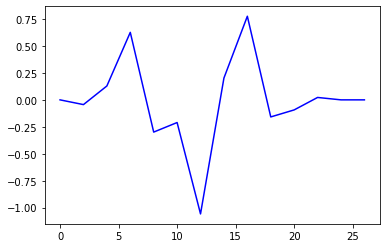

In [7]:
level = 2 # cambiar este parametro
phi_d, psi_d, phi_r, psi_r, x = myWavelet.wavefun(level)

step = 2
psi_x = [i for i in range(0, len(psi_d), step )]
psi_d_ = [psi_d[i] for i in range(0, len(psi_d), step)]
plt.plot(psi_x, psi_d_, 'b-')
plt.show()

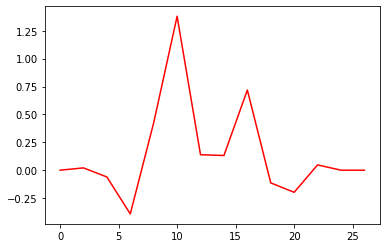

In [8]:
step = 2
phi_x = [i for i in range(0, len(phi_d), step)]
phi_d_ = [phi_d[i] for i in range(0, len(phi_d), step)]
plt.plot(phi_x, phi_d_, 'r-')
plt.show()

Esta es la señal de ejemplo principal

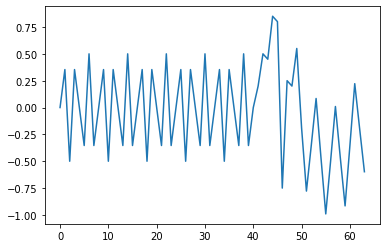

In [9]:
def signal(x, pattern):
    if 0 <= x <= 40:
        return math.cos((math.pi *27*x)/8)*math.sin((math.pi *75*x)/8)
    elif 41 <= x <= 49:
        return pattern[int(x)-41]
    elif 50 <= x <= 63:
        return math.cos((math.pi *295*x)/32)*math.sin((math.pi *105*x)/32)

x = np.arange(0, 64, 1)
y = [signal(i, pattern) for i in x]

plt.plot(x, y)
plt.show()

La señal se ve distinta a la del artículo. No sabemos exactamente por qué pasa esto.

Length of signal:64
Length of cA:32
Length of cD:32
the point in the dwt is: (23, 0) and in S is (23, 0.4952099185615049)


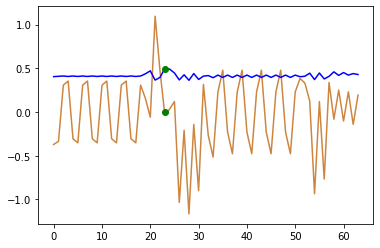

In [10]:
print(f'Length of signal:{len(y)}')
(cA, cD) = pywt.dwt(y, myWavelet,mode='per')
print(f'Length of cA:{len(cA)}')
print(f'Length of cD:{len(cD)}')
y = np.concatenate([cA, cD])

alpha = 0.1
s = [math.exp(-(np.abs(y[i])**alpha)) for i in range(len(y))]
x = [i for i in range(len(y))]
plt.plot(x, y, 'peru')
plt.plot(x, s, 'b-')

s_max = max(s)# buscando el valor mas cercano a 1 en S
x1_max = s.index(s_max)

plt.plot(x1_max, s_max, 'go')
plt.plot(x1_max, 0, 'go')
print(f'the point in the dwt is: ({x1_max}, 0) and in S is ({x1_max}, {s_max})')

plt.show()

La señal marrón es la concatenación de los coeficientes de la tranformada. En azul está la función que $S$ que definen en el artículo como:
$S(x) = e^{-{|DST(x)|}^{\alpha}}$. El punto verde es donde más se acerca a 1 $S$, que corresponde a los puntos más cercanos a 0 de DST.

Algo que notamos aquí es que nosotros pensabamos que si a una señal de tamaño $N$ se le hace la transformada se obtienen $N/2$ coeficientes de cada tipo, pero aquí se  obtienen más. No sabemos si es que esto puede pasar o es algún error.

Aquí desplazamos un poco el patrón dentro de la señal

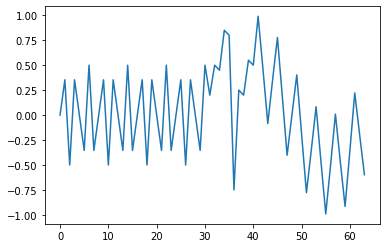

In [11]:
def signal(x, pattern):
    if 0 <= x <= 30:
        return math.cos((math.pi *27*x)/8)*math.sin((math.pi *75*x)/8)
    elif 31 <= x <= 39:
        return pattern[int(x)-31]
    elif 40 <= x <= 63:
        return math.cos((math.pi *295*x)/32)*math.sin((math.pi *105*x)/32)

x = np.arange(0, 64, 1)
y = [signal(i, pattern) for i in x]

plt.plot(x, y)
plt.show()

Length of signal:64
Length of cA:32
Length of cD:32
the point in the dwt is: (22, 0) and in S is (22, 0.4868331634928064)


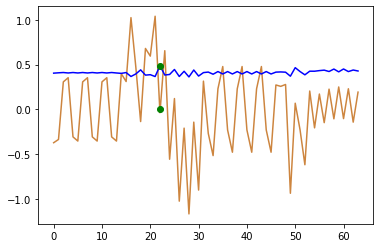

In [12]:
print(f'Length of signal:{len(y)}')
(cA, cD) = pywt.dwt(y, myWavelet, mode='per')
print(f'Length of cA:{len(cA)}')
print(f'Length of cD:{len(cD)}')
y = np.concatenate([cA, cD])

alpha = 0.1
s = [math.exp(-(np.abs(y[i])**alpha)) for i in range(len(y))]
x = [i for i in range(len(y))]
plt.plot(x, y, 'peru')
plt.plot(x, s, 'b-')

s_max = max(s)# buscando el valor mas cercano a 1 en S
x1_max = s.index(s_max)

plt.plot(x1_max, s_max, 'go')
plt.plot(x1_max, 0, 'go')
print(f'the point in the dwt is: ({x1_max}, 0) and in S is ({x1_max}, {s_max})')

plt.show()

Volvemos a desplazar el patrón

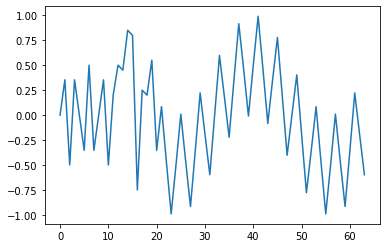

In [13]:
def signal(x, pattern):
    if 0 <= x <= 10:
        return math.cos((math.pi *27*x)/8)*math.sin((math.pi *75*x)/8)
    elif 11 <= x <= 19:
        return pattern[int(x)-11]
    elif 19 <= x <= 63:
        return math.cos((math.pi *295*x)/32)*math.sin((math.pi *105*x)/32)

x = np.arange(0, 64, 1)
y = [signal(i, pattern) for i in x]

plt.plot(x, y)
plt.show()

Length of signal:64
Length of cA:32
Length of cD:32
the point in the dwt is: (8, 0) and in S is (8, 0.5591706470526013)


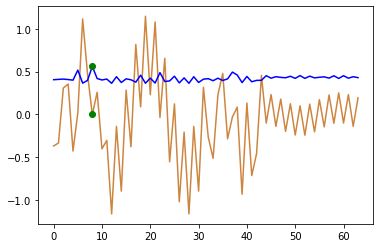

In [14]:
print(f'Length of signal:{len(y)}')
(cA, cD) = pywt.dwt(y, myWavelet,mode='per')
print(f'Length of cA:{len(cA)}')
print(f'Length of cD:{len(cD)}')
y = np.concatenate([cA, cD])

alpha = 0.1
s = [math.exp(-(np.abs(y[i])**alpha)) for i in range(len(y))]
x = [i for i in range(len(y))]
plt.plot(x, y, 'peru')
plt.plot(x, s, 'b-')

s_max = max(s)# buscando el valor mas cercano a 1 en S
x1_max = s.index(s_max)

plt.plot(x1_max, s_max, 'go')
plt.plot(x1_max, 0, 'go')
print(f'the point in the dwt is: ({x1_max}, 0) and in S is ({x1_max}, {s_max})')

plt.show()

## Experimentando con los filtros obtenidos en el articulo

In [15]:
from scripts.values import q_values, q_bar_values, p_values, p_bar_values
print(f'p: {p_values}\n')
print(f'q: {q_values}\n')
print(f'p_bar: {p_bar_values}\n')
print(f'q_bar: {q_bar_values}\n')

filter_bank = [
    list(p_values.values()),
    list(q_values.values()),
    list(p_bar_values.values()),
    list(q_bar_values.values())
]
myWavelet = pywt.Wavelet(name="myWavelet", filter_bank=filter_bank)

p: {p0: -0.1263, p1: 0.2277, p2: 0.2784, p3: 0.0091, p4: 0.7055, p5: 0.5719, p6: -0.1505, p7: -0.0834}

q: {q0: -0.0834, q1: 0.1505, q2: 0.5719, q3: -0.7055, q4: -0.0091, q5: -0.2784, q6: 0.2277, q7: 0.1263}

p_bar: {p_bar0: -0.0834, p_bar1: -0.1505, p_bar2: 0.5719, p_bar3: 0.7055, p_bar4: -0.0091, p_bar5: 0.2784, p_bar6: 0.2277, p_bar7: -0.1263}

q_bar: {q_bar0: 0.0834, q_bar1: 0.1505, q_bar2: -0.5719, q_bar3: -0.7055, q_bar4: 0.0091, q_bar5: -0.2784, q_bar6: -0.2277, q_bar7: 0.1263}



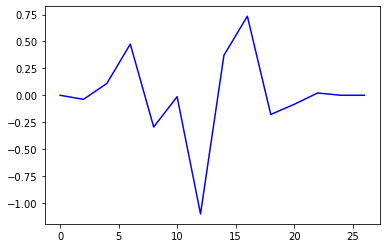

In [16]:
level = 2 # cambiar este parametro
phi_d, psi_d, phi_r, psi_r, x = myWavelet.wavefun(level)

step = 2
psi_x = [i for i in range(0, len(psi_d), step )]
psi_d_ = [psi_d[i] for i in range(0, len(psi_d), step)]
plt.plot(psi_x, psi_d_, 'b-')
plt.show()

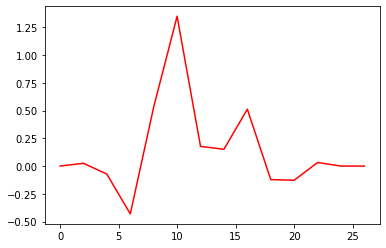

In [17]:
step = 2
phi_x = [i for i in range(0, len(phi_d), step)]
phi_d_ = [phi_d[i] for i in range(0, len(phi_d), step)]
plt.plot(phi_x, phi_d_, 'r-')
plt.show()

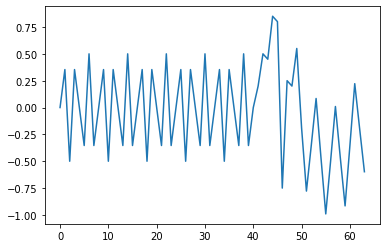

In [18]:
def signal(x, pattern):
    if 0 <= x <= 40:
        return math.cos((math.pi *27*x)/8)*math.sin((math.pi *75*x)/8)
    elif 41 <= x <= 49:
        return pattern[int(x)-41]
    elif 50 <= x <= 63:
        return math.cos((math.pi *295*x)/32)*math.sin((math.pi *105*x)/32)

x = np.arange(0, 64, 1)
y = [signal(i, pattern) for i in x]

plt.plot(x, y)
plt.show()

Length of signal:64
Length of cA:32
Length of cD:32
the point in the dwt is: (23, 0) and in S is (23, 0.4948368896725289)


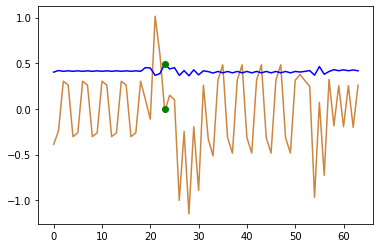

In [19]:
print(f'Length of signal:{len(y)}')
(cA, cD) = pywt.dwt(y, myWavelet,mode='per')
print(f'Length of cA:{len(cA)}')
print(f'Length of cD:{len(cD)}')
y = np.concatenate([cA, cD])

alpha = 0.1
s = [math.exp(-(np.abs(y[i])**alpha)) for i in range(len(y))]
x = [i for i in range(len(y))]
plt.plot(x, y, 'peru')
plt.plot(x, s, 'b-')

s_max = max(s) # buscando el valor mas cercano a 1 en S
x1_max = s.index(s_max)

plt.plot(x1_max, s_max, 'go')
plt.plot(x1_max, 0, 'go')
print(f'the point in the dwt is: ({x1_max}, 0) and in S is ({x1_max}, {s_max})')

plt.show()

Como  puede apreciar el resultado tampoco es muy bueno.Estamos pensando en implementar la transformada desde cero nosotros mismo para ver si tiene algo que ver con la forma en que funciona **PyWavelet**. Lo otro es quizá no entendemos bien como es que se identifica el patrón a partir de la transformada. 